---
#### 6-3. 딥러닝 
- 주요 개념 
---

In [20]:
import numpy as np
import matplotlib.pyplot as plt

#### 활성화 함수

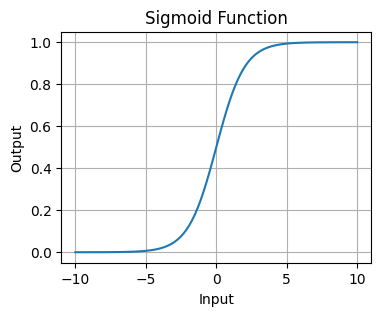

In [ ]:
# Sigmoid 함수 
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(4,3))
plt.plot(x, y)
plt.title("Sigmoid Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

입력값 = [-5 -1  0  1  5]
출력값 = [0.00669285 0.26894142 0.5        0.73105858 0.99330715]


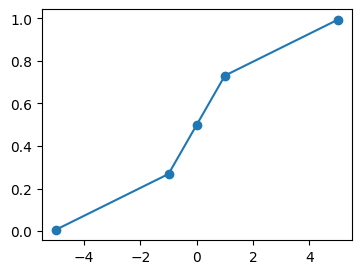

In [26]:
# 시그모이드 함수에 값 적용 결과 
inputs = np.array([-5, -1, 0, 1, 5])
outputs = sigmoid(inputs)
print('입력값 =', inputs)
print('출력값 =', outputs)

plt.figure(figsize=(4,3))
plt.plot(inputs, outputs, marker='o')

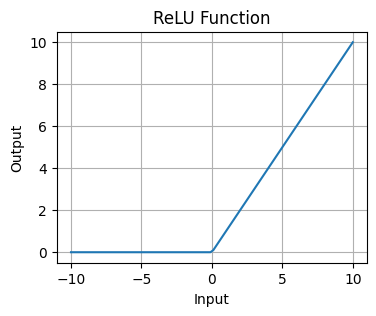

In [28]:
# ReLU
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 100)
y = relu(x)

plt.figure(figsize=(4,3))
plt.plot(x, y)
plt.title("ReLU Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

입력값 = [-5 -1  0  1  5]
출력값 = [0 0 0 1 5]


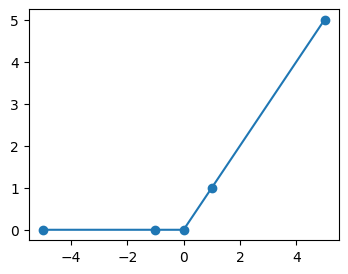

In [ ]:
inputs = np.array([-5, -1, 0, 1, 5])
outputs = relu(inputs)
print('입력값 =', inputs)
print('출력값 =', outputs)

plt.figure(figsize=(4,3))
plt.plot(inputs, outputs, marker='o')

In [33]:
# softmax
def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

inputs = np.array([2.0, 1.0, 0.1])
outputs = softmax(inputs)

print("입력:", inputs)
print("출력:", outputs)
print("합:", np.sum(outputs))

입력: [2.  1.  0.1]
출력: [0.65900114 0.24243297 0.09856589]
합: 1.0


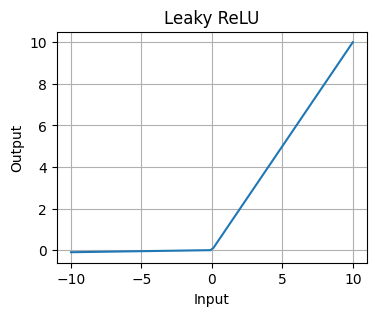

In [36]:
# Leaky ReLU
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-10, 10, 100)
y = leaky_relu(x)

plt.figure(figsize=(4,3))
plt.plot(x, y)
plt.title("Leaky ReLU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

입력값 = [-5 -1  0  1  5]
출력값 = [-0.05 -0.01  0.    1.    5.  ]


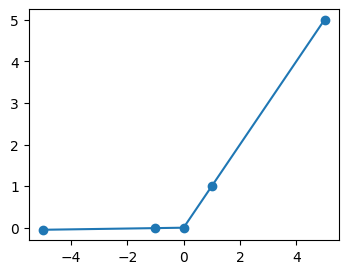

In [37]:
inputs = np.array([-5, -1, 0, 1, 5])
outputs = leaky_relu(inputs)
print('입력값 =', inputs)
print('출력값 =', outputs)

plt.figure(figsize=(4,3))
plt.plot(inputs, outputs, marker='o')

#### 손실함수

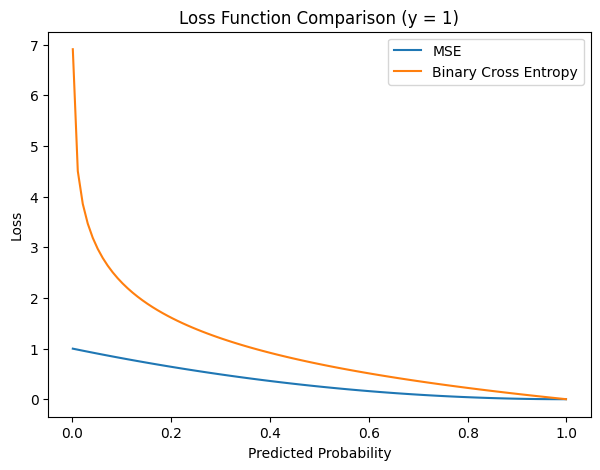

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 예측 확률 범위
p = np.linspace(0.001, 0.999, 100)

# 실제값 (정답)
y = 1

# MSE
mse = (y - p) ** 2

# Binary Cross Entropy
bce = -(y*np.log(p) + (1-y)*np.log(1-p))

# 시각화
plt.figure(figsize=(7,5))

plt.plot(p, mse, label='MSE')
plt.plot(p, bce, label='Binary Cross Entropy')

plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.title("Loss Function Comparison (y = 1)")
plt.legend()

plt.show()

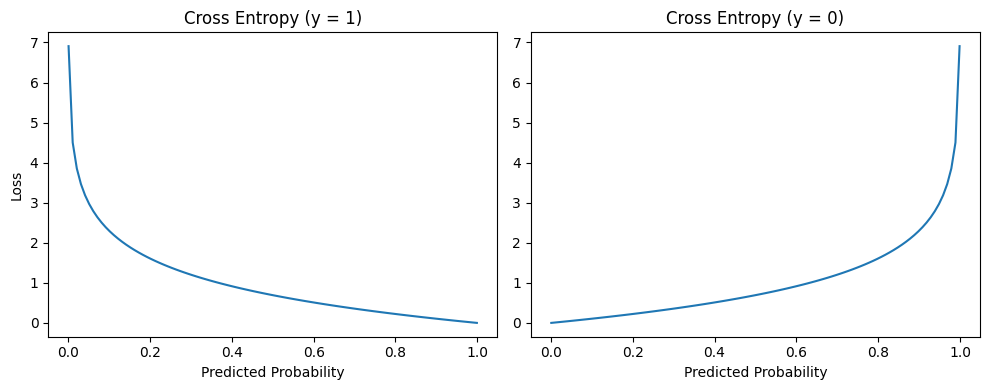

In [3]:
# 예측 확률 범위
p = np.linspace(0.001, 0.999, 100)

# 실제값
y1 = 1
y0 = 0

# Binary Cross Entropy
bce_y1 = -(y1*np.log(p) + (1-y1)*np.log(1-p))
bce_y0 = -(y0*np.log(p) + (1-y0)*np.log(1-p))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# 실제값 = 1
axes[0].plot(p, bce_y1)
axes[0].set_title("Cross Entropy (y = 1)")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Loss")

# 실제값 = 0
axes[1].plot(p, bce_y0)
axes[1].set_title("Cross Entropy (y = 0)")
axes[1].set_xlabel("Predicted Probability")

plt.tight_layout()
plt.show()

#### 경사 하강법

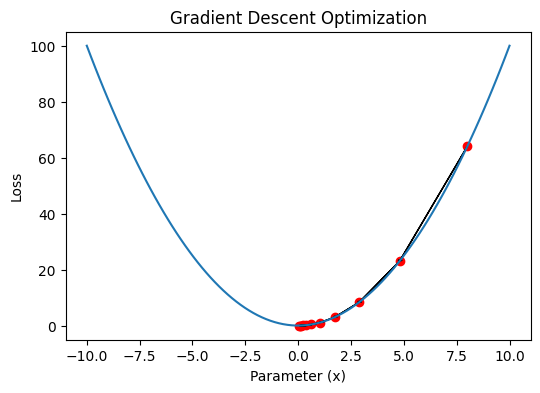

In [4]:
# 손실함수
def loss(x):
    return x**2

# gradient
def grad(x):
    return 2*x

# 초기값
x = 8
lr = 0.2

x_history = [x]

# gradient descent
for i in range(10):
    x = x - lr * grad(x)
    x_history.append(x)

# 그래프용 x
x_vals = np.linspace(-10,10,100)
y_vals = loss(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals, label='Loss function')

# 이동 경로
plt.scatter(x_history, loss(np.array(x_history)), color='red')

for i in range(len(x_history)-1):
    plt.arrow(x_history[i], loss(x_history[i]),
              x_history[i+1]-x_history[i],
              loss(x_history[i+1])-loss(x_history[i]),
              head_width=0.2, length_includes_head=True)

plt.title("Gradient Descent Optimization")
plt.xlabel("Parameter (x)")
plt.ylabel("Loss")
plt.show()